<a href="https://colab.research.google.com/github/Elight-dotcom/data-mining/blob/main/DM_M6_3124600100_Ardanu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M5 - Validation Model of Classification - Data Mining

Nama : Ardanu Egitya Ash Shafah  
NRP : 3124600100  
Kelas : D4 IT D

## Menampilkan dataset titanic.csv

In [ ]:
import pandas as pd

data_path = '/content/drive/MyDrive/PENS/Semester 5/Data Mining/titanic.csv'
dataset = pd.read_csv(data_path)

dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Menampilkan dataset titanic_test.csv

In [ ]:
data_test_path = '/content/drive/MyDrive/PENS/Semester 5/Data Mining/titanic_test.csv'
test_dataset = pd.read_csv(data_test_path)

test_dataset

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


## Ambil dataset titanic tertentu dan isi missing value

In [ ]:
features = ['Sex', 'Age', 'Pclass', 'Fare']

train_data = dataset[features].copy()

# Encoding Sex
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})

# Isi missing value dengan mean per class
age_mean  = train_data.groupby('Pclass')['Age'].mean()
fare_mean = train_data.groupby('Pclass')['Fare'].mean()

train_data['Age']  = train_data['Age'].fillna(train_data['Pclass'].map(age_mean))
train_data['Fare'] = train_data['Fare'].fillna(train_data['Pclass'].map(fare_mean))

train_data

,Sex,Age,Pclass,Fare
0,0,22.00000,3,7.2500
1,1,38.00000,1,71.2833
2,1,26.00000,3,7.9250
3,1,35.00000,1,53.1000
4,0,35.00000,3,8.0500
...,...,...,...,...
886,0,27.00000,2,13.0000
887,1,19.00000,1,30.0000
888,1,25.14062,3,23.4500
889,0,26.00000,1,30.0000


## Ambil dataset titanic_test tertentu

In [ ]:
test_data = test_dataset[features].copy()

# Encoding Sex
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

# Pengisian Missing value
test_data['Age']  = test_data['Age'].fillna(test_data['Pclass'].map(age_mean))
test_data['Fare'] = test_data['Fare'].fillna(test_data['Pclass'].map(fare_mean))

test_data

,Sex,Age,Pclass,Fare
0,0,34.50000,3,7.8292
1,1,47.00000,3,7.0000
2,0,62.00000,2,9.6875
3,0,27.00000,3,8.6625
4,1,22.00000,3,12.2875
...,...,...,...,...
413,0,25.14062,3,8.0500
414,1,39.00000,1,108.9000
415,0,38.50000,3,7.2500
416,0,25.14062,3,8.0500


## Ambil dataset kolom survived

In [ ]:
train_label = dataset['Survived']

train_label

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


## Ambil titanic_testlabel.csv

In [ ]:
data_test_label_path = '/content/drive/MyDrive/PENS/Semester 5/Data Mining/titanic_testlabel.csv'
test_label = pd.read_csv(data_test_label_path)
test_label = test_label['Survived']

test_label

,Survived
0,0
1,1
2,0
3,0
4,1
...,...
413,0
414,1
415,0
416,0


## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc=DecisionTreeClassifier(criterion='gini')
dtc.fit(train_data, train_label)
class_result=dtc.predict(test_data)

acc=dtc.score(test_data, test_label)
print("Error Ratio (test):", round((1 - acc) * 100, 2), "%")

Error Ratio (test): 22.01 %


## Export dalam bentuk grafis

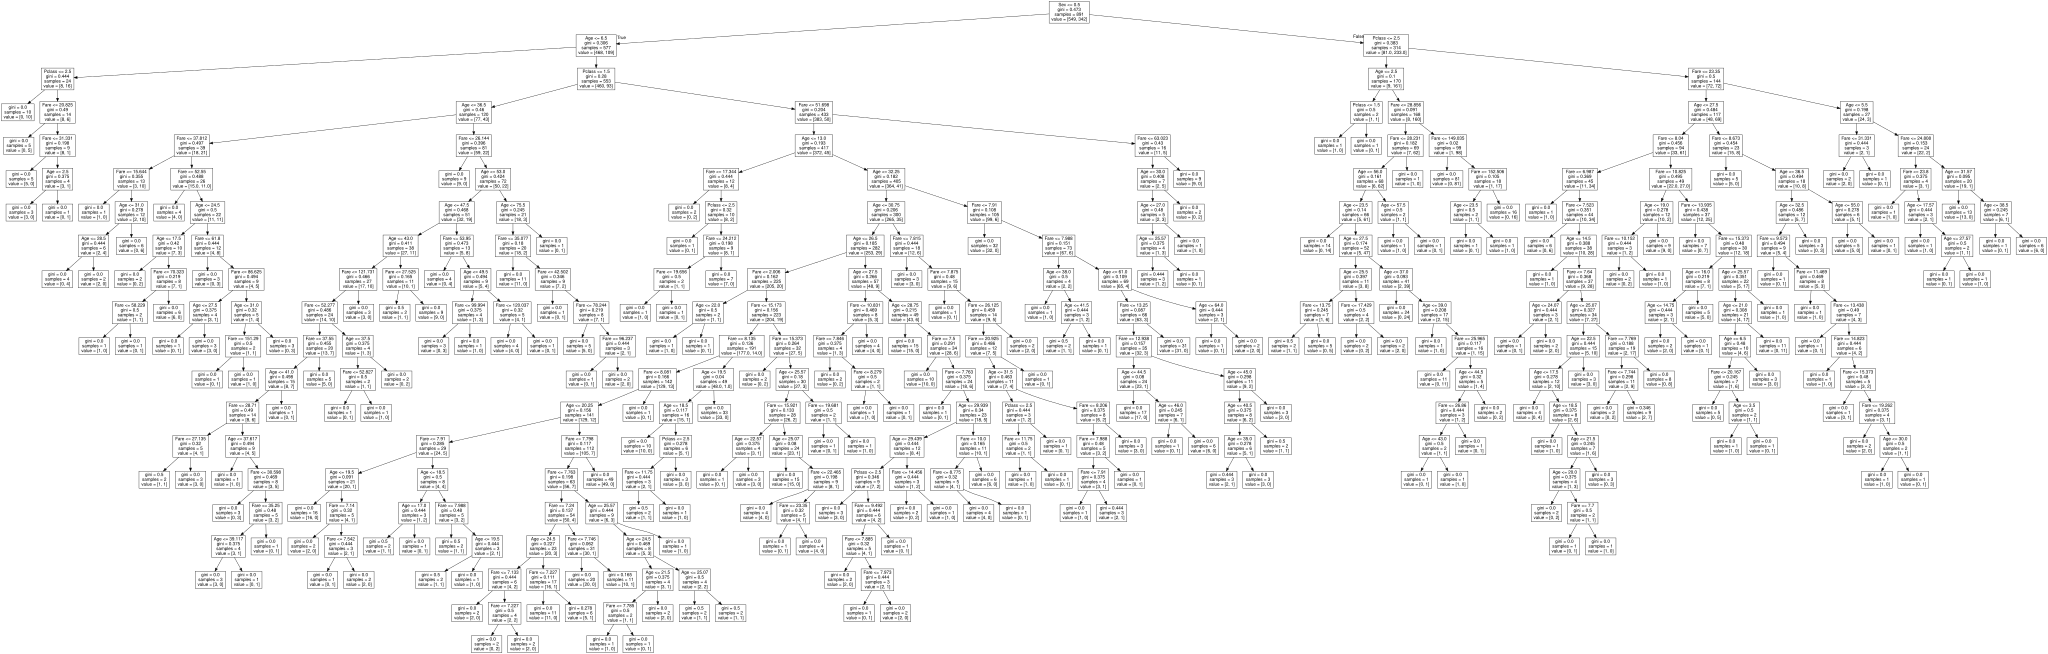

In [ ]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import graphviz

dot_data = tree.export_graphviz(dtc, out_file=None,
  feature_names=train_data.columns.values)

graph = graphviz.Source(dot_data)
graph.render(filename='hasil_decision_tree', format='png', cleanup=True)
graph